<a href="https://colab.research.google.com/github/maryamhasnaasyamila/machine-learning/blob/tugas/praktikum/praktikum11/Maryam_Hasnaa'_Syamila_0110222067_PraktikumMandiri11.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Praktikum Mandiri 11 - Clustering (DBSCAN)**

*   **Nama :** Maryam Hasnaa' Syamila
*   **NIM :** 0110222067



#### **Install Library**

In [1]:
!pip install folium

#### **Import Library**

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score

import folium
from folium.plugins import HeatMap

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 6)

#### **Load Dataset**

In [4]:
# sinkronisasi dengan drive
from google.colab import drive
drive.mount('/content/drive')

data_path = "/content/drive/My Drive/SEMESTER 7/Machine Learning/praktikum11/datasets/google_places_data.csv"
df = pd.read_csv(data_path)

# Cek struktur awal dataset
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,business_id,phone_number,name,full_address,latitude,longitude,review_count,rating,timezone,website,...,Tuesday_afternoon,Tuesday_evening,Wednesday_morning,Wednesday_afternoon,Wednesday_evening,Thursday_morning,Thursday_afternoon,Thursday_evening,geo_cluster,country
0,0x3e6751d65629cb05:0x27cbb7ddadc7008c,Unknown,حصن الظفرة Al Dhafra Fort,PXMJ+H7J حصن الظفرة Al Dhafra Fort - Unnamed R...,23.733973,53.980629,58.0,4.7,Asia/Dubai,Unknown,...,0,0,0,0,0,0,0,0,0.0,United Arab Emirates
1,0x3e675d61493af035:0xa4f20f24f9e8beb7,971569049905,Rafiullah,MP4R+WQJ Rafiullah - Zayed City - Abu Dhabi - ...,23.657332,53.741881,3.0,3.0,Asia/Dubai,Unknown,...,1,1,1,1,1,1,1,1,0.0,United Arab Emirates
2,0x3e91f7041ac64d33:0x6120c5af14b63b93,96822081500,National Museum of Oman,"National Museum of Oman, opposite Al Alam Pala...",23.611601,58.593728,3499.0,4.6,Asia/Muscat,https://www.nm.gov.om/,...,0,0,0,0,0,0,0,0,0.0,Oman
3,0x487bb1e7815c44db:0x417132a42bd93ef6,443300580058,Science and Industry Museum,"Science and Industry Museum, Liverpool Rd, Man...",53.477136,-2.254582,17398.0,4.4,Europe/London,https://www.scienceandindustrymuseum.org.uk/,...,0,0,0,0,0,0,0,0,2.0,United Kingdom
4,0x487e78e1955eb419:0x4c55c87f0a46d173,441913704000,"Beamish, the Living Museum of the North","Beamish, the Living Museum of the North, Stanl...",54.884752,-1.659321,21957.0,4.8,Europe/London,https://www.beamish.org.uk/,...,0,0,0,0,0,0,0,0,2.0,United Kingdom


In [5]:
# Info tipe data dan jumlah record
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15203 entries, 0 to 15202
Data columns (total 46 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   business_id          15203 non-null  object 
 1   phone_number         15203 non-null  object 
 2   name                 15203 non-null  object 
 3   full_address         15203 non-null  object 
 4   latitude             15198 non-null  float64
 5   longitude            15198 non-null  float64
 6   review_count         15203 non-null  float64
 7   rating               15203 non-null  float64
 8   timezone             15203 non-null  object 
 9   website              15203 non-null  object 
 10  place_id             15203 non-null  object 
 11  place_link           15203 non-null  object 
 12  types                15203 non-null  object 
 13  Friday               15203 non-null  object 
 14  Saturday             15203 non-null  object 
 15  Sunday               15203 non-null 

#### **Cleaning Data**

In [6]:
# Cek ketersediaan kolom yang akan dipakai
needed_cols = ['latitude', 'longitude', 'rating', 'review_count']
for c in needed_cols:
    print(c, "->", c in df.columns)

latitude -> True
longitude -> True
rating -> True
review_count -> True


In [7]:
# Ambil subset kolom yang relevan untuk analisis
df_ml = df[needed_cols].copy()

# Cek missing value
df_ml.isnull().sum()

,0
latitude,5
longitude,5
rating,0
review_count,0


In [8]:
# Drop baris yang tidak punya koordinat
df_ml = df_ml.dropna(subset=['latitude', 'longitude'])

# Untuk rating & review_count, kalau ada NaN isi dengan median
for col in ['rating', 'review_count']:
    median_val = df_ml[col].median()
    df_ml[col] = df_ml[col].fillna(median_val)

# Cek duplikasi
df_ml.duplicated().sum()

np.int64(334)

In [9]:
# Hapus duplikasi jika ada
df_ml = df_ml.drop_duplicates()

df_ml.describe()

,latitude,longitude,rating,review_count
count,14864.000000,14864.000000,14864.000000,14864.000000
mean,33.297032,24.020696,4.285455,722.966227
std,12.300871,50.835152,0.675447,5719.856651
min,-45.577163,-157.870613,1.000000,1.000000
25%,25.260690,5.244331,4.100000,8.000000
50%,25.314826,55.283245,4.400000,32.000000
75%,45.873630,55.371306,4.700000,117.000000
max,70.032732,176.230310,5.000000,256877.000000


#### **Exploratory Data Analysis Singkat**

#### **Distribusi Rating & Review**

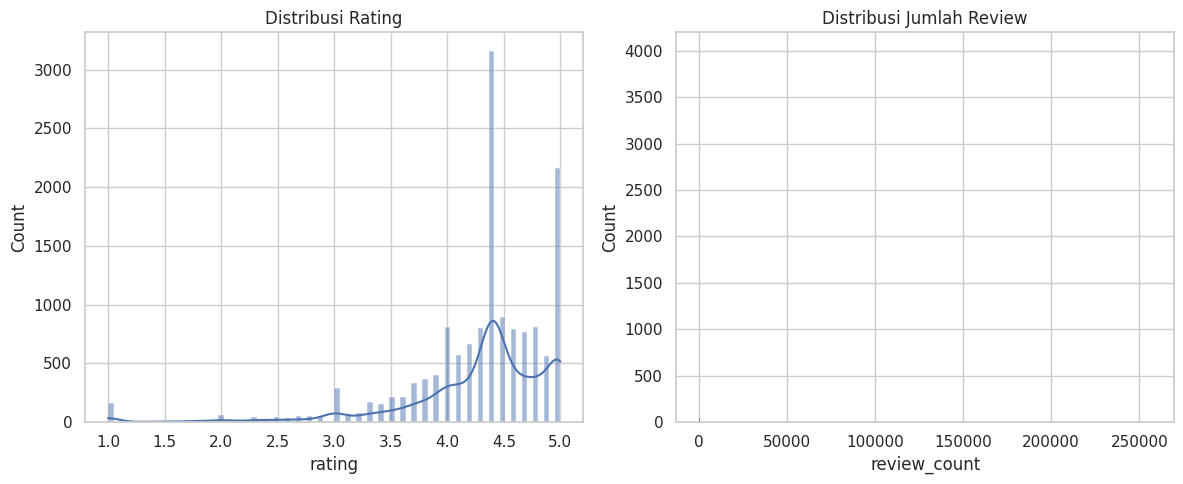

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.histplot(df_ml['rating'], kde=True, ax=axes[0])
axes[0].set_title('Distribusi Rating')

sns.histplot(df_ml['review_count'], kde=False, ax=axes[1])
axes[1].set_title('Distribusi Jumlah Review')

plt.tight_layout()
plt.show()

#### **Heatmap Persebaran Lokasi (Peta GPS)**

In [11]:
# Tentukan titik tengah peta (rata-rata koordinat)
center_lat = df_ml['latitude'].mean()
center_lon = df_ml['longitude'].mean()

m_heat = folium.Map(location=[center_lat, center_lon],
                    zoom_start=11,
                    tiles='OpenStreetMap')

# Data untuk heatmap: [lat, lon]
heat_data = df_ml[['latitude', 'longitude']].values.tolist()

HeatMap(heat_data,
        radius=8,
        blur=10,
        max_zoom=15).add_to(m_heat)

m_heat

#### **Normalisasi Data untuk DBSCAN**

In [12]:
features = ['latitude', 'longitude', 'rating', 'review_count']

X = df_ml[features].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled[:5]

array([[-0.77745557,  0.58937448,  0.61375487, -0.11625966],
       [-0.78368634,  0.58467781, -1.90317995, -0.12587561],
       [-0.78740411,  0.68012378,  0.46569988,  0.48534908],
       [ 1.64059788, -0.5168896 ,  0.1695899 ,  2.91538682],
       [ 1.75503399, -0.50517957,  0.76180986,  3.71246158]])

#### **Menentukan Nilai eps dengan K-Distance Graph**

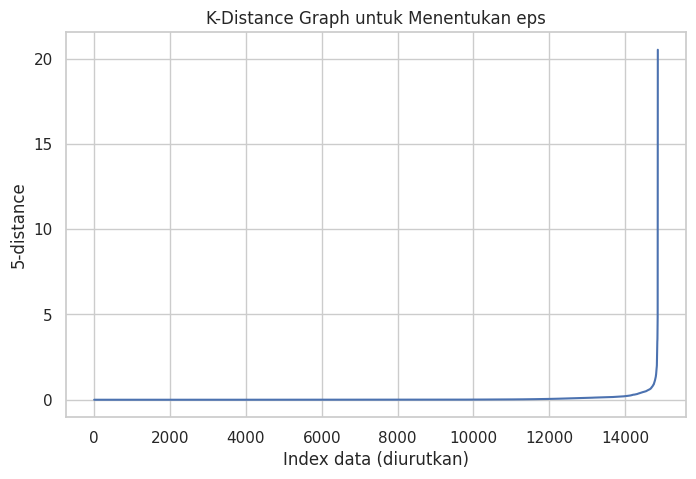

In [13]:
k = 5

neigh = NearestNeighbors(n_neighbors=k)
neigh.fit(X_scaled)

distances, indices = neigh.kneighbors(X_scaled)

# Ambil jarak ke tetangga ke-k
k_distances = np.sort(distances[:, k-1])

plt.figure(figsize=(8,5))
plt.plot(k_distances)
plt.ylabel(f'{k}-distance')
plt.xlabel('Index data (diurutkan)')
plt.title('K-Distance Graph untuk Menentukan eps')
plt.grid(True)
plt.show()

#### **Implementasi DBSCAN & info cluster**

In [16]:
from sklearn.cluster import DBSCAN

# Model DBSCAN
eps = 0.08
min_samples = 5

dbscan = DBSCAN(eps=eps, min_samples=min_samples)
labels = dbscan.fit_predict(X_scaled)

# Simpan label ke dataframe
df_ml['cluster'] = labels

# Hitung jumlah cluster (tanpa noise) dan noise
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
n_noise = list(labels).count(-1)

print(f"Jumlah cluster (tanpa noise): {n_clusters}")
print(f"Jumlah noise (label -1)    : {n_noise}")
print("\nDistribusi anggota tiap cluster:")
print(df_ml['cluster'].value_counts().sort_index())

Jumlah cluster (tanpa noise): 164
Jumlah noise (label -1)    : 1996

Distribusi anggota tiap cluster:
cluster
-1      1996
 0       406
 1       217
 2        11
 3      1510
        ... 
 159       5
 160       6
 161       5
 162       5
 163       6
Name: count, Length: 165, dtype: int64


#### **Evaluasi dengan Silhoutte Score**

In [17]:
from sklearn.metrics import silhouette_score
import numpy as np

# buang noise agar lebih stabil
mask = df_ml['cluster'] != -1
unique_clusters = df_ml.loc[mask, 'cluster'].nunique()

if unique_clusters > 1 and mask.sum() > 1:
    sil = silhouette_score(X_scaled[mask], df_ml.loc[mask, 'cluster'])
    print(f"Silhouette Score (tanpa noise): {sil:.3f}")
else:
    print("Silhouette score tidak bisa dihitung (cluster terlalu sedikit).")


Silhouette Score (tanpa noise): 0.684


#### **Visualisasi hasil clustering (scatter koordinat GPS)**

/tmp/ipython-input-2547223377.py:19: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


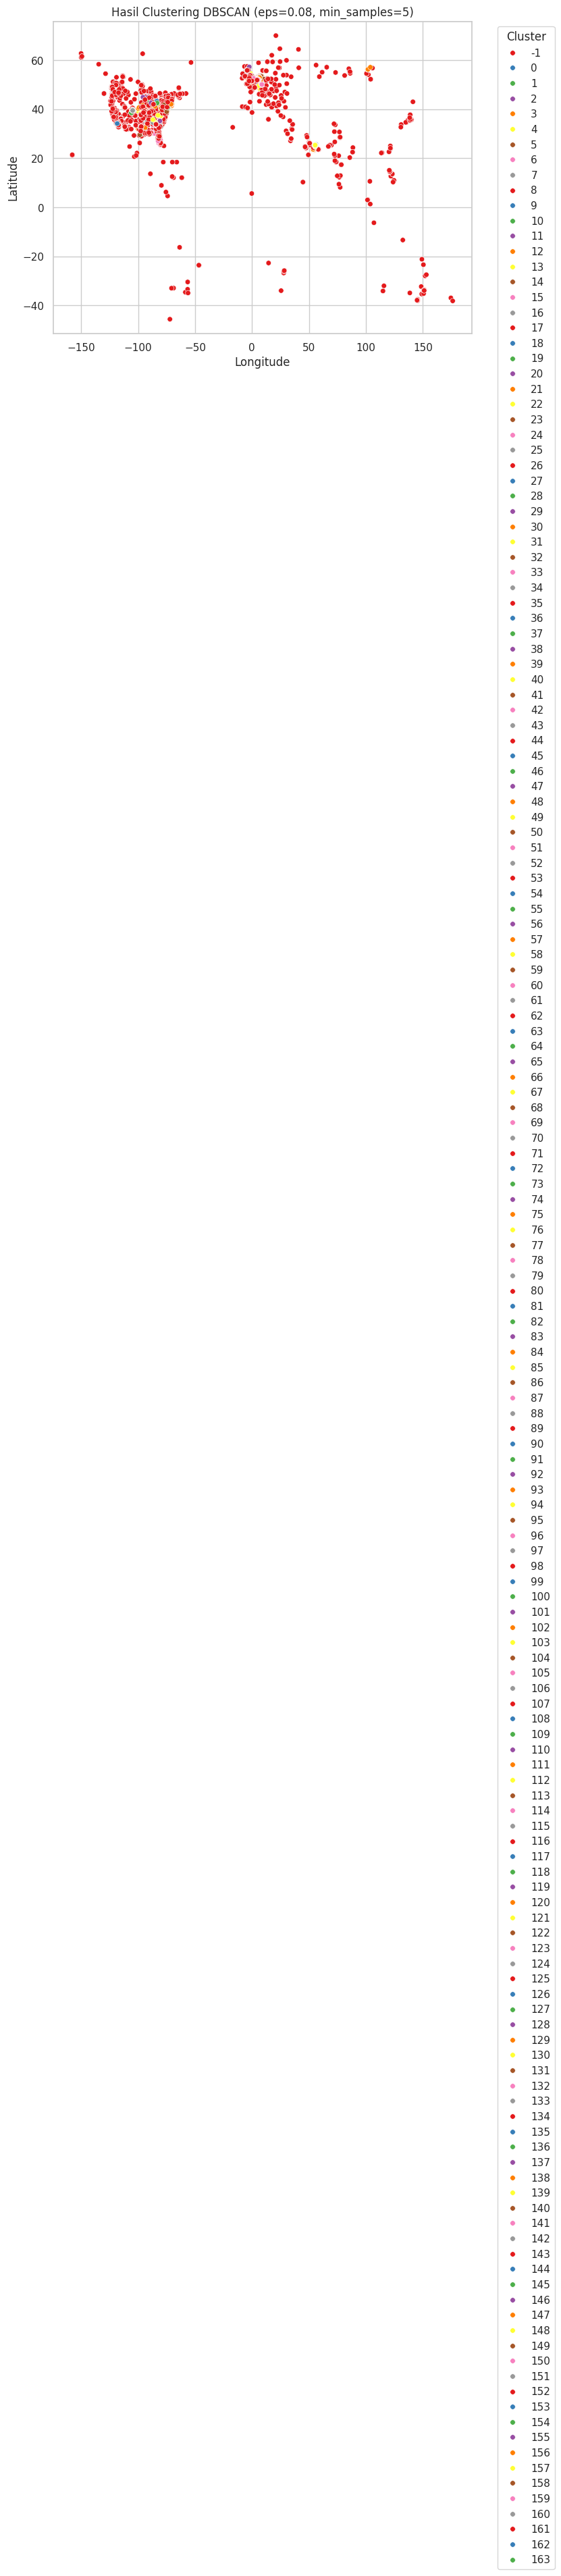

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df_ml,
    x='longitude',
    y='latitude',
    hue='cluster',
    palette='Set1',
    s=30
)

plt.title(f'Hasil Clustering DBSCAN (eps={eps}, min_samples={min_samples})')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

#### **Visualisasi 2D dengan PCA**

/tmp/ipython-input-1841305863.py:20: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


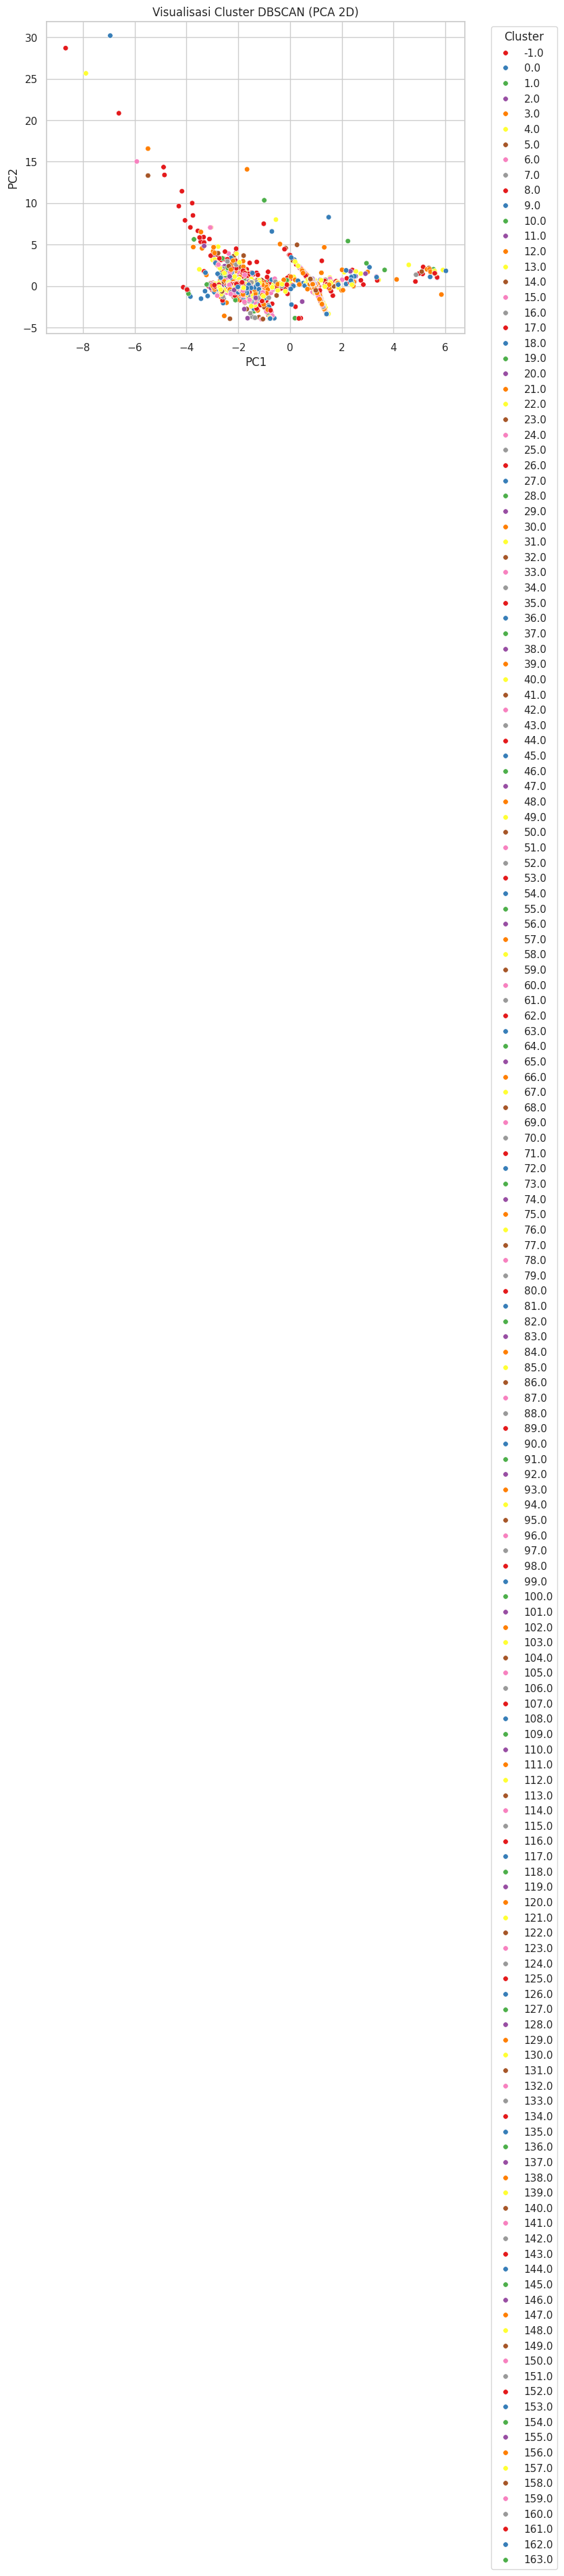

In [19]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

df_pca = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
df_pca['cluster'] = df_ml['cluster']

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df_pca,
    x='PC1',
    y='PC2',
    hue='cluster',
    palette='Set1',
    s=30
)
plt.title('Visualisasi Cluster DBSCAN (PCA 2D)')
plt.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

#### **Ringkasan Karakteristik Tiap Cluster (Analisis Klaster & Noise)**

In [20]:
cluster_summary = df_ml.groupby('cluster').agg(
    jumlah_titik   = ('latitude', 'count'),
    mean_rating    = ('rating', 'mean'),
    mean_review    = ('review_count', 'mean')
).round(2)

cluster_summary

,jumlah_titik,mean_rating,mean_review
cluster,,,
-1,1996,4.22,4653.06
0,406,4.70,123.98
1,217,3.00,9.04
2,11,4.50,262.73
3,1510,5.00,16.63
...,...,...,...
159,5,4.70,181.00
160,6,4.60,414.50
161,5,4.50,206.80


#### **Visualisasi Peta GPS (Folium) per cluster**

In [21]:
import folium

# Titik tengah peta
center_lat = df_ml['latitude'].mean()
center_lon = df_ml['longitude'].mean()

m_cluster = folium.Map(location=[center_lat, center_lon],
                       zoom_start=11,
                       tiles='OpenStreetMap')

# Fungsi warna per cluster
def get_color(c):
    if c == -1:
        return 'gray'  # noise
    colors = ['red', 'blue', 'green', 'purple', 'orange',
              'darkred', 'cadetblue', 'darkgreen', 'darkblue']
    return colors[int(c) % len(colors)]

# Agar peta tidak berat kalau data > 2000
sample_df = df_ml.copy()
if len(sample_df) > 2000:
    sample_df = sample_df.sample(2000, random_state=42)

for _, row in sample_df.iterrows():
    folium.CircleMarker(
        location=[row['latitude'], row['longitude']],
        radius=4,
        color=get_color(row['cluster']),
        fill=True,
        fill_opacity=0.7,
        popup=(f"Cluster: {row['cluster']}<br>"
               f"Rating: {row['rating']}<br>"
               f"Review: {row['review_count']}")
    ).add_to(m_cluster)

m_cluster

#### **Simpan Model DBSCAN**

In [22]:
from google.colab import drive
drive.mount('/content/drive')
import joblib

save_path = "/content/drive/My Drive/SEMESTER 7/Machine Learning/praktikum11/models/dbscan_model.pkl"

joblib.dump(dbscan, save_path)

print("Model DBSCAN berhasil disimpan di:", save_path)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Model DBSCAN berhasil disimpan di: /content/drive/My Drive/SEMESTER 7/Machine Learning/praktikum11/models/dbscan_model.pkl


#### **Simpan hasil clustering ke CSV**

In [23]:
csv_path = "/content/drive/My Drive/SEMESTER 7/Machine Learning/praktikum11/models/hasil_dbscan_googlemap.csv"

df_ml.to_csv(csv_path, index=False)

print("File hasil clustering berhasil disimpan di:", csv_path)

File hasil clustering berhasil disimpan di: /content/drive/My Drive/SEMESTER 7/Machine Learning/praktikum11/models/hasil_dbscan_googlemap.csv
